In [1]:
import numpy as np
import ee
import geemap

ee.Authenticate()
ee.Initialize()

In [2]:
map = geemap.Map()
map.add_basemap("HYBRID")
center = ee.Geometry.Point([46.439209, 30.949347])
map.centerObject(center, 4)

map

Map(center=[30.949347000000003, 46.439209], controls=(WidgetControl(options=['position', 'transparent_bg'], po…

In [3]:
roi = map.draw_last_feature.geometry()
#print("ROI geometry:", roi)

In [4]:
# Creating a timelist
time_start = ee.Date('2005')
time_end = ee.Date('2010')
time_dif = time_end.difference(time_start, 'year').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'year')
)

# Function for obtaining the date for the spicfic time
def annual(date, col):
  start_date = ee.Date(date)
  end_date = start_date.advance(1, 'year')
  img_sum = col.filterDate(start_date, end_date).sum()
  return img_sum.set('system:time_start', start_date.millis())

In [5]:
vis_params4 =  {'bands': ['NDVI'], 'min': -7970.3, 'max': 87319.55, 'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']}

In [7]:
# Script in the cell is Demo
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(time_start, time_end)
    .select("NDVI")
    .map(lambda x: x.multiply(0.0001).copyProperties(x, ['system:time_start'])
    )
)

ndvi_annual = ee.ImageCollection(time_list.map(lambda x: annual(date=x, col=ndvi)))

In [8]:
map.addLayer(ndvi.select(['NDVI']).mean().clip(roi), vis_params4, "NDVI")

In [9]:
# Add one NDVI layer for each year (toggle in the layer manager)
annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

for i in range(5):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    map.addLayer(
        annual_img.clip(roi),
        {'bands': ['NDVI'], 'min': -7970.3, 'max': 87319.55, 'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']},
        f'NDVI {year_label}',
        False
    )

map

Map(bottom=7001.0, center=[31.109388560814963, 44.417724609375], controls=(WidgetControl(options=['position', …

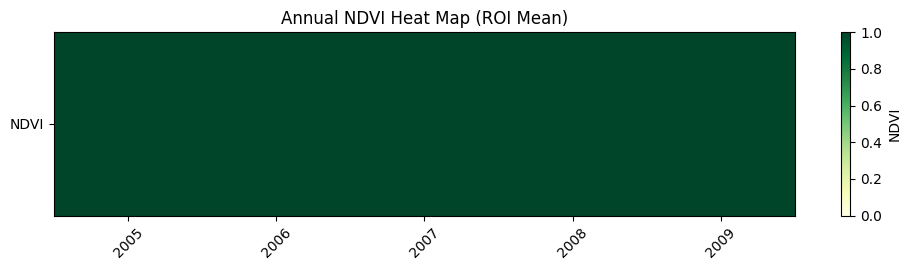

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Plot all yearly NDVI values in one heat map (ROI mean per year)
annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()

    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(ndvi_value)

heat = np.array(mean_ndvi, dtype=float).reshape(1, -1)

plt.figure(figsize=(max(10, len(years) * 0.6), 2.8))
im = plt.imshow(heat, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
plt.yticks([0], ['NDVI'])
plt.xticks(range(len(years)), years, rotation=45)
plt.title('Annual NDVI Heat Map (ROI Mean)')
cbar = plt.colorbar(im)
cbar.set_label('NDVI')
plt.tight_layout()
plt.show()

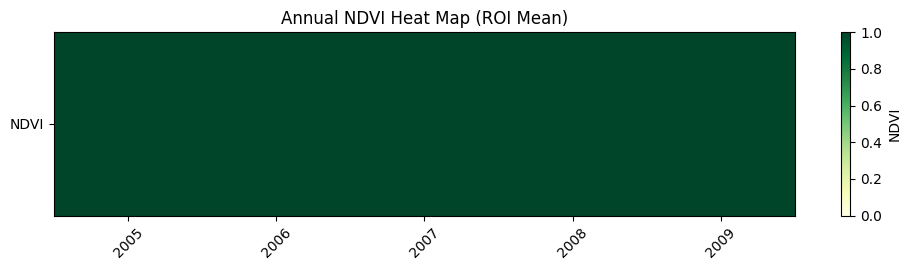

In [11]:
# NDVI HEATMAP (all years in one plot)
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()
years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()
    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(ndvi_value)

heat = np.array(mean_ndvi, dtype=float).reshape(1, -1)
plt.figure(figsize=(max(10, len(years) * 0.6), 2.8))
im = plt.imshow(heat, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
plt.yticks([0], ['NDVI'])
plt.xticks(range(len(years)), years, rotation=45)
plt.title('Annual NDVI Heat Map (ROI Mean)')
cbar = plt.colorbar(im)
cbar.set_label('NDVI')
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.


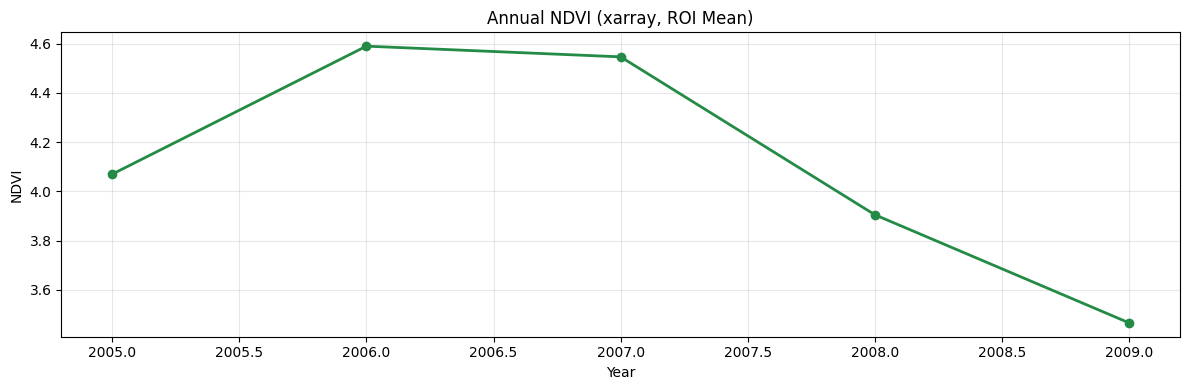

<xarray.DataArray 'NDVI' (year: 5)> Size: 40B
array([4.06995113, 4.58985306, 4.54648287, 3.90523034, 3.466306  ])
Coordinates:
  * year     (year) int64 40B 2005 2006 2007 2008 2009

In [12]:
%pip install xarray
# Convert annual NDVI to xarray and plot all years in one figure
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()

    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(float(ndvi_value))

ndvi_xr = xr.DataArray(
    data=np.array(mean_ndvi, dtype=float),
    coords={'year': np.array(years, dtype=int)},
    dims=['year'],
    name='NDVI'
)

fig, ax = plt.subplots(figsize=(12, 4))
ndvi_xr.plot(ax=ax, marker='o', linewidth=2, color='#238b45')
ax.set_title('Annual NDVI (xarray, ROI Mean)')
ax.set_xlabel('Year')
ax.set_ylabel('NDVI')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ndvi_xr

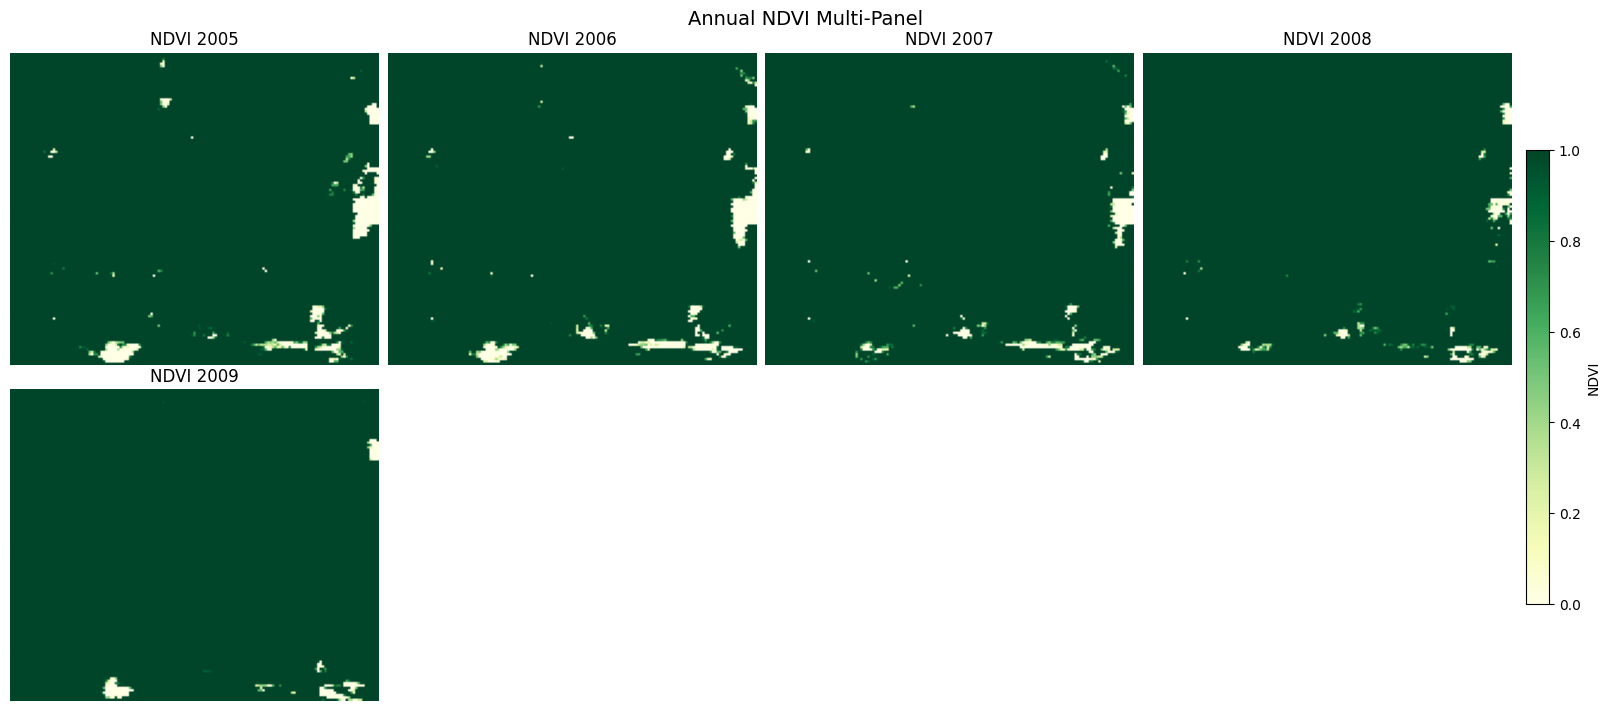

In [13]:
# Multi-panel NDVI plot: one panel per year/image
import math
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    years.append(year_label)
    arrays.append(arr)

if not arrays:
    raise ValueError('No NDVI images were converted to arrays. Check ROI and scale.')

n = len(arrays)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, (year_label, arr) in enumerate(zip(years, arrays)):
    im = axes[idx].imshow(arr, cmap='YlGn', vmin=0, vmax=1)
    axes[idx].set_title(f'NDVI {year_label}')
    axes[idx].axis('off')

for idx in range(n, len(axes)):
    axes[idx].axis('off')

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.7, pad=0.01)
cbar.set_label('NDVI')
fig.suptitle('Annual NDVI Multi-Panel', fontsize=14)
plt.show()